In [1]:
import xarray as xr
import numpy as np
import xesmf as xe

# for year in {1940..2020}; do cdo monmean $year/ice.$year.nc $year/ice_monthly.$year.nc; done
# for year in {1958..2020}; do cdo -gtc,0 $year/ice_monthly.$year.nc $year/ice_mask.$year.nc; done

YEAR_START = 1959
YEAR_FIN = 2019

out_var_type = 'atm'

PATH = "/glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_all/MONTHLY/"

PATH_landmask = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_1990_1999/cpl/hist/'
filename_raw = 'a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_1990_1999.cpl.hi.2000-01-01-00000.nc'

if out_var_type == 'ocn':
    output_lat = xr.open_dataset(PATH_landmask + filename_raw, engine="netcdf4")['ocnExp_lat'].isel(time=0).drop_vars('time').rename({"ocnExp_ny": "y", "ocnExp_nx": "x"})
    output_lon = xr.open_dataset(PATH_landmask + filename_raw, engine="netcdf4")['ocnExp_lon'].isel(time=0).drop_vars('time').rename({"ocnExp_ny": "y", "ocnExp_nx": "x"})
elif out_var_type == 'atm':
    output_lat = xr.open_dataset(PATH_landmask + filename_raw, engine="netcdf4")['atmImp_lat'].isel(time=0).drop_vars('time').rename({"atmImp_ny": "y", "atmImp_nx": "x"})
    output_lon = xr.open_dataset(PATH_landmask + filename_raw, engine="netcdf4")['atmImp_lon'].isel(time=0).drop_vars('time').rename({"atmImp_ny": "y", "atmImp_nx": "x"})

PATH_icemask = "/glade/campaign/cgd/oce/people/rita/ERA5/"

if out_var_type == 'ocn':
    variables = {
        "latent": "ocnExp_Foxx_lat",
        "sensible": "ocnExp_Foxx_sen",
        "swnet": "ocnExp_Foxx_swnet",
        "lwnet": "ocnExp_Foxx_lwnet"
    }
elif out_var_type == 'atm':
    variables = {
        "atm_swnet": "atmImp_Faxa_swnet"
    }

icemask_filename = 'ERA5_ice_mask_monthly_1940_2020.nc'

mask_ds =  xr.open_dataset(PATH_icemask + icemask_filename)

In [2]:
def convert_ocnExp_to_atmImp_mask(PATH, filename):
    '''
    PATH - path to raw model output files 
    filename - filename of one of these files (to read coords of ocnExp and atmImp)
    '''
    lat_in = xr.open_dataset(PATH + filename)['ocnExp_lat'].isel(time=0, drop = True)
    lon_in = xr.open_dataset(PATH + filename)['ocnExp_lon'].isel(time=0, drop = True) % 360

    mask = xr.open_dataset(PATH + filename, engine="netcdf4")['ocnImp_So_omask'].isel(time=0, drop = True).rename({"ocnImp_ny": "ocnExp_ny", "ocnImp_nx": "ocnExp_nx"})
    
    mask_in = xr.DataArray(mask.values, dims=("y", "x"),
                           coords={"lon": (("y", "x"), lon_in.values), "lat": (("y", "x"), lat_in.values)},
                           name="mask")
    
    
    lat_out = xr.open_dataset(PATH + filename)['atmImp_lat'].isel(time=0, drop = True)
    lon_out = xr.open_dataset(PATH + filename)['atmImp_lon'].isel(time=0, drop = True)
    
    # Create xESMF regridder for curvilinear grid
    grid_in = xr.Dataset({"lat": (("y", "x"), lat_in.values), "lon": (("y", "x"), lon_in.values)})
    grid_out = xr.Dataset({"lat": (("y", "x"), lat_out.values), "lon": (("y", "x"), lon_out.values)})
    
    regridder = xe.Regridder(grid_in, grid_out, "nearest_s2d")  # 'nearest_s2d' is best for masks
    
    # Apply regridding
    mask_out = regridder(mask_in)
    mask_out = mask_out.rename("mask")  # Explicitly set the name

    mask_out_da = xr.DataArray(mask_out.values, dims=("y", "x"),
                       coords={"longitude": (("y", "x"), lon_out.values), "latitude": (("y", "x"), lat_out.values)},
                       name="mask")


    return mask_out_da

In [3]:
if out_var_type == 'ocn':
    land_mask = xr.open_dataset(PATH_landmask + filename_raw, engine="netcdf4")['ocnImp_So_omask'].isel(time=0).drop_vars('time').rename({"ocnImp_ny": "y", "ocnImp_nx": "x"})
    land_mask = land_mask.where(land_mask != 0, np.nan)

elif out_var_type == 'atm':
    land_mask = convert_ocnExp_to_atmImp_mask(PATH_landmask, filename_raw)
    land_mask = land_mask.where(land_mask != 0, np.nan)

In [4]:
# do we need these for ocn vars??

# # Shift longitudes to be within [-180, 180]
# output_lon = (output_lon + 360) % 360  # First, ensure longitudes are in [0, 360]
# output_lon = ((output_lon + 180) % 360) - 180  # Convert to [-180, 180]

# # Convert longitudes from [0, 360] to [-180, 180]
# mask_ds["longitude"] = ((mask_ds["longitude"] + 180) % 360) - 180

In [6]:
for YEAR in range(YEAR_START, YEAR_FIN+1):  
    print(YEAR)
    for var_type, var_name in variables.items():
        # Load model data
        model_file = f"{PATH}{YEAR}.{var_type}.monthly.nc"
        model_ds = xr.open_dataset(model_file)

        if out_var_type == 'ocn':
            model_var = model_ds[var_name].rename({"ocnExp_ny": "y", "ocnExp_nx": "x"})
        elif out_var_type == 'atm':
            model_var = model_ds[var_name].rename({"atmImp_ny": "y", "atmImp_nx": "x"})

        mask_var = mask_ds["ice_cov"].sel(time=mask_ds.time.dt.year == YEAR)#.sortby('longitude')


        # Convert ice mask to binary (NaN where ice > 0, 1 elsewhere)
        ice_mask = xr.where(mask_var > 0, np.nan, 1)

        # Rename dimensions if necessary
        ice_mask = ice_mask.rename({"latitude": "y", "longitude": "x"})
        # ice_mask = ice_mask.rename({"lat": "y", "lon": "x"})

        # Ensure time alignment
        ice_mask["time"] = model_var["time"]

        # print(model_var)
        # print(ice_mask)
        # print(land_mask)

        # Apply ice mask and land mask
        masked_model = model_var * ice_mask * land_mask

        # Convert to dataset with proper variable name
        masked_model = masked_model.to_dataset(name=var_name)

        # Save masked data
        output_file = f"{PATH}{YEAR}.{var_type}.monthly_ice_mask.nc"
        masked_model.to_netcdf(output_file)

        print(f"Processed: {output_file}")

1959
Processed: /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_all/MONTHLY/1959.atm_swnet.monthly_ice_mask.nc
1960
Processed: /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_all/MONTHLY/1960.atm_swnet.monthly_ice_mask.nc
1961
Processed: /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_all/MONTHLY/1961.atm_swnet.monthly_ice_mask.nc
1962
Processed: /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_all/MONTHLY/1962.atm_swnet.monthly_ice_mask.nc
1963
Processed: /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_all/MONTHLY/1963.atm_swnet.monthly_ice_mask.nc
1964
Processed: /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_ERA5.TL319_t232.daily_SST_ERA5_all/MONTHLY/1964.atm_swnet.monthly_ice_mask.nc
1965
Processed: /glade/campaign/cgd/oce/people/rita/CESM_OUTPUT/a.e30.A_ERA5.TL319_t232.daily_SST_ER

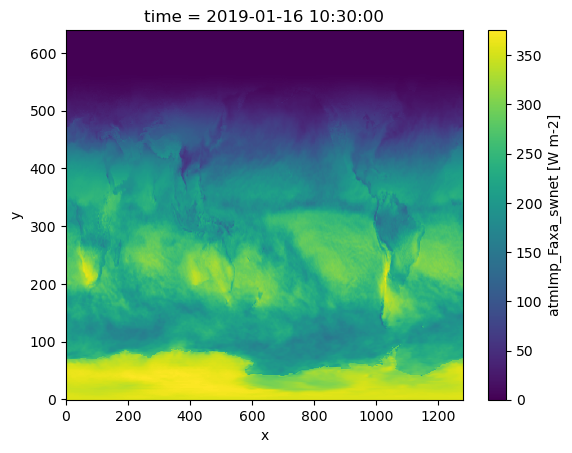

In [7]:
model_var.isel(time=0).plot()

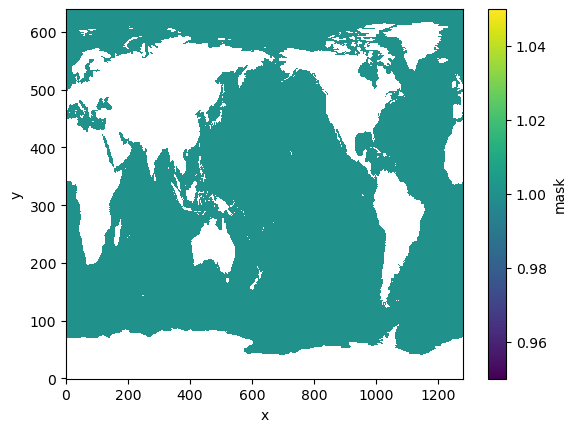

In [8]:
land_mask.plot()

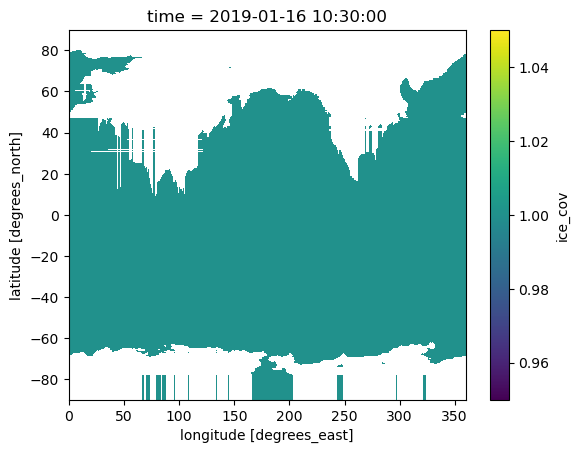

In [9]:
ice_mask.isel(time=0).plot()

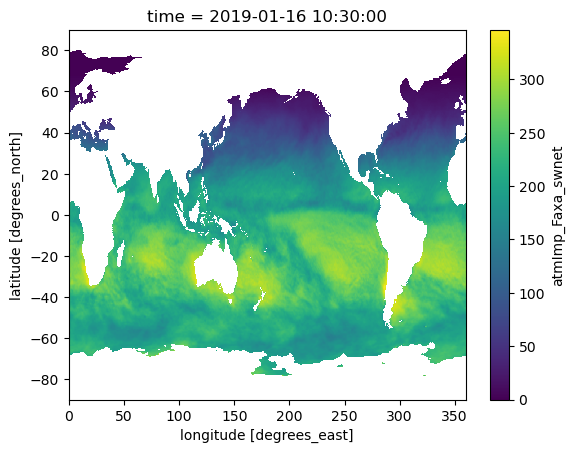

In [10]:
masked_model.atmImp_Faxa_swnet.isel(time=0).plot()